# Comprehensive Evaluation Results Analysis Notebook

**⚠️ IMPORTANT: This notebook ONLY analyzes locally stored results.**
- ✅ Reads CSV files from disk across multiple result directories
- ✅ Generates comprehensive visualizations and statistics
- ✅ Compares strategies across k values, overlap sizes, and chunk configurations
- ❌ Does NOT query Pinecone
- ❌ Does NOT query Gemini or any APIs
- ❌ Does NOT require API keys

**Workflow:**
1. **Generate Results** (with API access): Run `generate_evaluation_results.py`
   - This queries Pinecone/Gemini and saves CSV files locally
   - Requires API keys and internet connection
   
2. **Analyze Results** (no API access needed): Run this notebook
   - Loads pre-generated CSV files from multiple directories
   - Generates comprehensive visualizations and comparisons
   - Can run offline after results are generated

**Strategies evaluated:**
- **baseline**: Simple character-based chunking
- **sentence**: Sentence-aware chunking  
- **adaptive**: Dynamic strategy selection based on document type

**Comparisons performed:**
- For each strategy: Compare performance across k values (k3, k5, k10)
- For each strategy: Compare performance across overlap sizes
- For each strategy: Compare performance across chunk sizes (small, medium)

**Usage:**
1. First, run `generate_evaluation_results.py` to generate CSV results
2. Then run this notebook to visualize and analyze the results across all configurations

All plots will be displayed inline for easy viewing and analysis.

## 1. Setup and Configuration

In [6]:
import sys
from pathlib import Path
from collections import defaultdict

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for inline plots
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configuration - Load results from all available directories
BASE_DIR = Path(".")
RESULTS_DIRS = {
    "k3": BASE_DIR / "results_k3",
    "k5": BASE_DIR / "results_k5", 
    "k10": BASE_DIR / "results_k10",
    "small_chunks": BASE_DIR / "chunk_config_evaluations" / "small_chunks" / "evaluation_results",
    "medium_chunks": BASE_DIR / "chunk_config_evaluations" / "medium_chunks" / "evaluation_results",
    "small_overlap": BASE_DIR / "chunk_config_evaluations" / "small_overlap" / "evaluation_results",
}

ENABLE_ANSWER_ANALYSIS = False  # Set to True if you have answer data in results

print("✅ Imports loaded successfully!")
print(f"📁 Working directory: {Path.cwd()}")
print(f"📊 Looking for results in: {", ".join(RESULTS_DIRS.keys())}")


✅ Imports loaded successfully!
📁 Working directory: c:\Users\LENOVO\OneDrive - Technion\Desktop\DataSience\semester8\lab2\evaluation
📊 Looking for results in: k3, k5, k10, small_chunks, medium_chunks, small_overlap


In [7]:
# Load all available evaluation results
all_results = {}
all_strategy_stats = {}
all_namespace_stats = {}

print("📂 Loading evaluation results from all directories...\n")

for config_name, config_dir in RESULTS_DIRS.items():
    csv_path = config_dir / "evaluation_results.csv"
    stats_path = config_dir / "strategy_statistics.csv"
    namespace_path = config_dir / "namespace_statistics.csv"
    
    if csv_path.exists():
        df_config = pd.read_csv(csv_path, encoding="utf-8")
        df_config['config'] = config_name  # Add configuration identifier
        all_results[config_name] = df_config
        print(f"✅ Loaded {len(df_config)} results from {config_name}")
        
        if stats_path.exists():
            stats = pd.read_csv(stats_path, encoding="utf-8")
            stats['config'] = config_name
            all_strategy_stats[config_name] = stats
            
        if namespace_path.exists():
            ns_stats = pd.read_csv(namespace_path, encoding="utf-8")
            ns_stats['config'] = config_name
            all_namespace_stats[config_name] = ns_stats
    else:
        print(f"⚠️  Results not found in {config_name}: {csv_path}")

# Combine all results
if all_results:
    df = pd.concat(all_results.values(), ignore_index=True)
    print(f"\n✅ Combined {len(df)} evaluation results from {len(all_results)} configurations")
    print(f"📊 Strategies: {", ".join(df["strategy"].unique())}")
    print(f"📝 Queries: {df["query"].nunique()}")
    print(f"📋 Configurations: {", ".join(df["config"].unique())}")
    print(f"\n📋 Sample data:")
    print(df.head())
    
    # Combine strategy stats if available
    strategy_stats = None
    if all_strategy_stats:
        strategy_stats = pd.concat(all_strategy_stats.values(), ignore_index=True)
        print(f"\n✅ Loaded strategy statistics from {len(all_strategy_stats)} configurations")
    
    # Combine namespace stats if available
    namespace_stats = None
    if all_namespace_stats:
        namespace_stats = pd.concat(all_namespace_stats.values(), ignore_index=True)
        print(f"✅ Loaded namespace statistics from {len(all_namespace_stats)} configurations")
else:
    print("\n❌ No evaluation results found! Please run generate_evaluation_results.py first.")
    raise FileNotFoundError("No evaluation results found")


📂 Loading evaluation results from all directories...

✅ Loaded 20 results from k3
✅ Loaded 20 results from k5
✅ Loaded 20 results from k10
✅ Loaded 60 results from small_chunks
✅ Loaded 60 results from medium_chunks
✅ Loaded 60 results from small_overlap

✅ Combined 240 evaluation results from 6 configurations
📊 Strategies: adaptive, baseline, sentence
📝 Queries: 20
📋 Configurations: k3, k5, k10, small_chunks, medium_chunks, small_overlap

📋 Sample data:
                                               query category  strategy  \
0                                 איך משלמים ארנונה?  general  adaptive   
1                  מה שעות הפעילות של המוקד העירוני?  general  adaptive   
2   מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?  general  adaptive   
3  האם ניתן ליצור קשר עם המוקד העירוני בנושאים שו...  general  adaptive   
4               אם אני רוצה לשלם ארנונה — למי פונים?  general  adaptive   

  expected_namespace detected_namespace  namespace_correct  avg_score  \
0             arn

## 3. Compute Statistics (if not already computed)

In [8]:
# Compute statistics if not already loaded
if strategy_stats is None:
    print("📊 Computing strategy statistics...")
    strategy_stats = df.groupby("strategy").agg({
        "avg_score": ["mean", "std", "min", "max"],
        "max_score": ["mean", "std"],
        "namespace_correct": "mean",
        "num_results": "mean",
        "unique_docs": "mean",
    }).round(4)
    strategy_stats.columns = ["_".join(col).strip() for col in strategy_stats.columns]
    strategy_stats = strategy_stats.reset_index()
    print("✅ Strategy statistics computed")

if namespace_stats is None:
    print("📊 Computing namespace statistics...")
    # Filter out rows with empty expected_namespace values
    df_with_namespace = df[df["expected_namespace"].notna() & (df["expected_namespace"].str.strip() != "")]
    if len(df_with_namespace) > 0:
        namespace_stats = df_with_namespace.groupby(["expected_namespace", "strategy"]).agg({
            "namespace_correct": ["mean", "count"],
        }).round(4)
        namespace_stats.columns = ["accuracy", "count"]
        namespace_stats = namespace_stats.reset_index()
        print("✅ Namespace statistics computed")
    else:
        namespace_stats = pd.DataFrame(columns=["expected_namespace", "strategy", "accuracy", "count"])
        print("⚠️ No namespace data available (expected_namespace column is empty)")

# Display statistics
print("\n📈 Strategy Statistics:")
print(strategy_stats.to_string(index=False))
print("\n📈 Namespace Statistics:")
print(namespace_stats.head(10))


📈 Strategy Statistics:
strategy  avg_score_mean  avg_score_std  avg_score_min  avg_score_max  max_score_mean  max_score_std  namespace_correct_mean  num_results_mean  unique_docs_mean  precision_mean  precision_std  recall_mean  recall_std  accuracy_mean  accuracy_std        config
adaptive          0.5259         0.1247         0.2677         0.6881          0.5443         0.1179                     1.0               3.0              2.40            0.10         0.2190       0.1000      0.2190           0.10        0.2190            k3
adaptive          0.5166         0.1284         0.2517         0.6812          0.5443         0.1179                     1.0               5.0              3.50            0.08         0.1765       0.1333      0.2942           0.08        0.1765            k5
adaptive          0.5030         0.1347         0.2281         0.6748          0.5443         0.1179                     1.0              10.0              6.20            0.06         0.1188     

## 4. Visualizations - Strategy Comparison

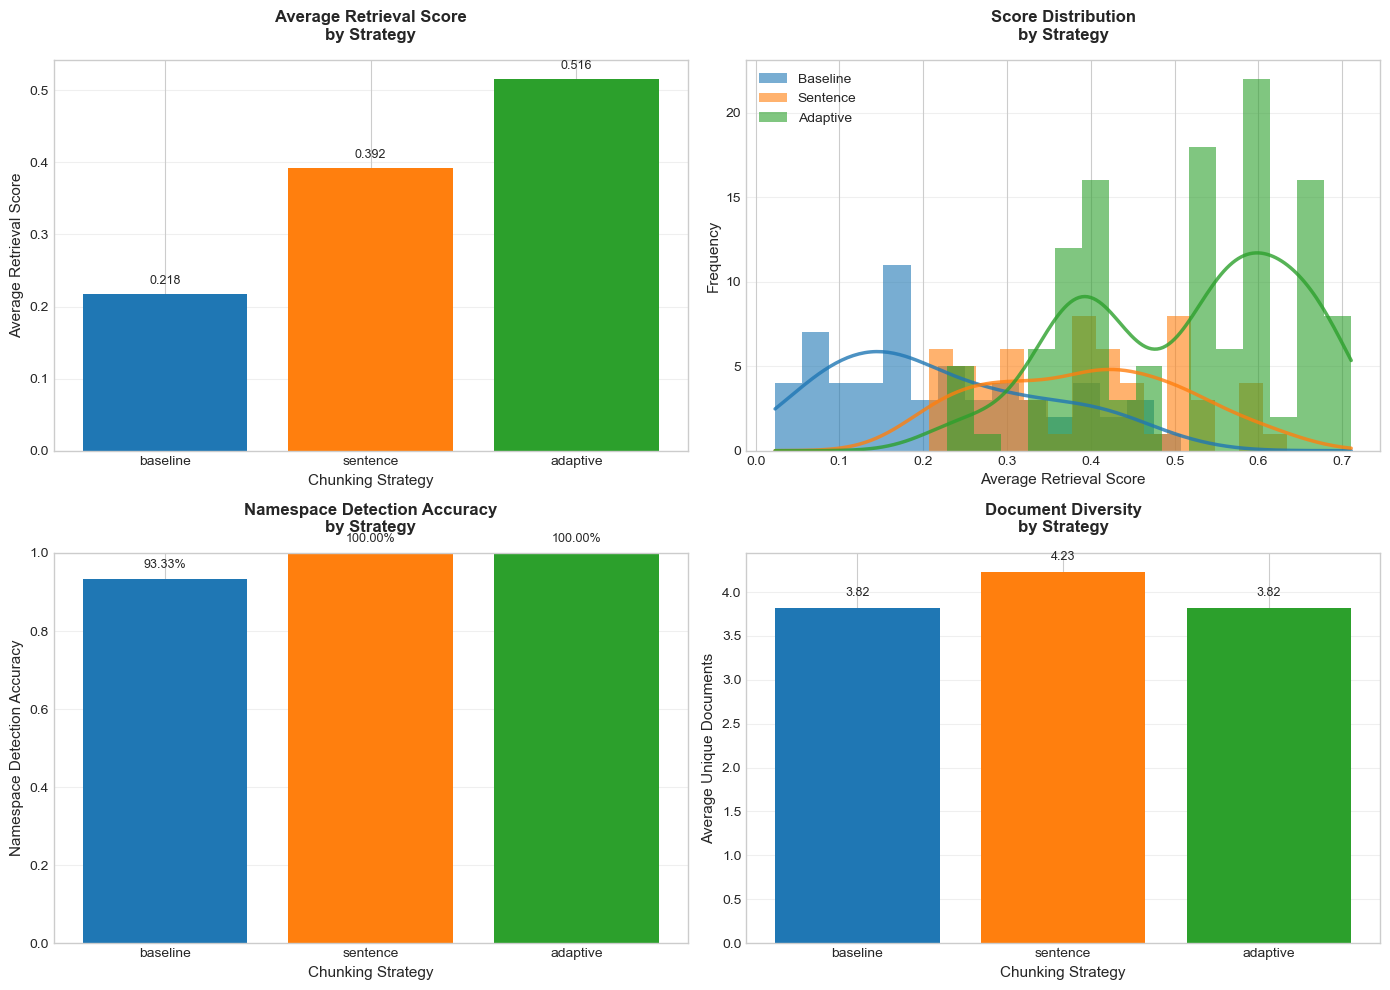

✅ Saved plot to results\strategy_comparison.png


In [90]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define consistent order and colors
strategy_order = ["baseline", "sentence", "adaptive"]
strategy_colors = {"baseline": "#1f77b4", "sentence": "#ff7f0e", "adaptive": "#2ca02c"}

# Strategy comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average score comparison
ax = axes[0, 0]
strategy_means = df.groupby("strategy")["avg_score"].mean().reindex(strategy_order)
ax.bar(strategy_means.index, strategy_means.values,
       color=[strategy_colors[s] for s in strategy_means.index])
ax.set_ylabel("Average Retrieval Score", fontsize=11)
ax.set_xlabel("Chunking Strategy", fontsize=11)
ax.set_title("Average Retrieval Score\nby Strategy", fontsize=12, fontweight="bold", pad=15)
ax.grid(axis="y", alpha=0.3)
for i, (strategy, val) in enumerate(strategy_means.items()):
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Score distribution
ax = axes[0, 1]
# Get all scores to determine x-axis range
all_scores = df["avg_score"].values
x_min, x_max = all_scores.min(), all_scores.max()
x_range = np.linspace(x_min, x_max, 200)

for strategy in strategy_order:
    scores = df[df["strategy"] == strategy]["avg_score"].values
    if len(scores) > 0:
        # Plot histogram
        n, bins, patches = ax.hist(scores, alpha=0.6, label=strategy.capitalize(), bins=15, 
                                   color=strategy_colors[strategy], density=False)
        
        # Calculate and plot KDE (density curve) scaled to match histogram frequency
        if len(scores) > 1:
            kde = stats.gaussian_kde(scores)
            density = kde(x_range)
            # Scale density to match histogram scale (multiply by number of data points and bin width)
            bin_width = bins[1] - bins[0]
            density_scaled = density * len(scores) * bin_width
            ax.plot(x_range, density_scaled, color=strategy_colors[strategy], 
                   linewidth=2.5, linestyle='-', alpha=0.8)
ax.set_xlabel("Average Retrieval Score", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Score Distribution\nby Strategy", fontsize=12, fontweight="bold", pad=15)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Namespace accuracy
ax = axes[1, 0]
namespace_acc = df.groupby("strategy")["namespace_correct"].mean().reindex(strategy_order)
ax.bar(namespace_acc.index, namespace_acc.values,
       color=[strategy_colors[s] for s in namespace_acc.index])
ax.set_ylabel("Namespace Detection Accuracy", fontsize=11)
ax.set_xlabel("Chunking Strategy", fontsize=11)
ax.set_title("Namespace Detection Accuracy\nby Strategy", fontsize=12, fontweight="bold", pad=15)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
for i, (strategy, val) in enumerate(namespace_acc.items()):
    ax.text(i, val + 0.02, f"{val:.2%}", ha="center", va="bottom", fontsize=9)

# Unique documents
ax = axes[1, 1]
unique_docs_means = df.groupby("strategy")["unique_docs"].mean().reindex(strategy_order)
ax.bar(unique_docs_means.index, unique_docs_means.values,
       color=[strategy_colors[s] for s in unique_docs_means.index])
ax.set_ylabel("Average Unique Documents", fontsize=11)
ax.set_xlabel("Chunking Strategy", fontsize=11)
ax.set_title("Document Diversity\nby Strategy", fontsize=12, fontweight="bold", pad=15)
ax.grid(axis="y", alpha=0.3)
for i, (strategy, val) in enumerate(unique_docs_means.items()):
    ax.text(i, val + 0.1, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "strategy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved plot to {RESULTS_DIR / 'strategy_comparison.png'}")

## 5. Visualization - Namespace Accuracy Heatmap

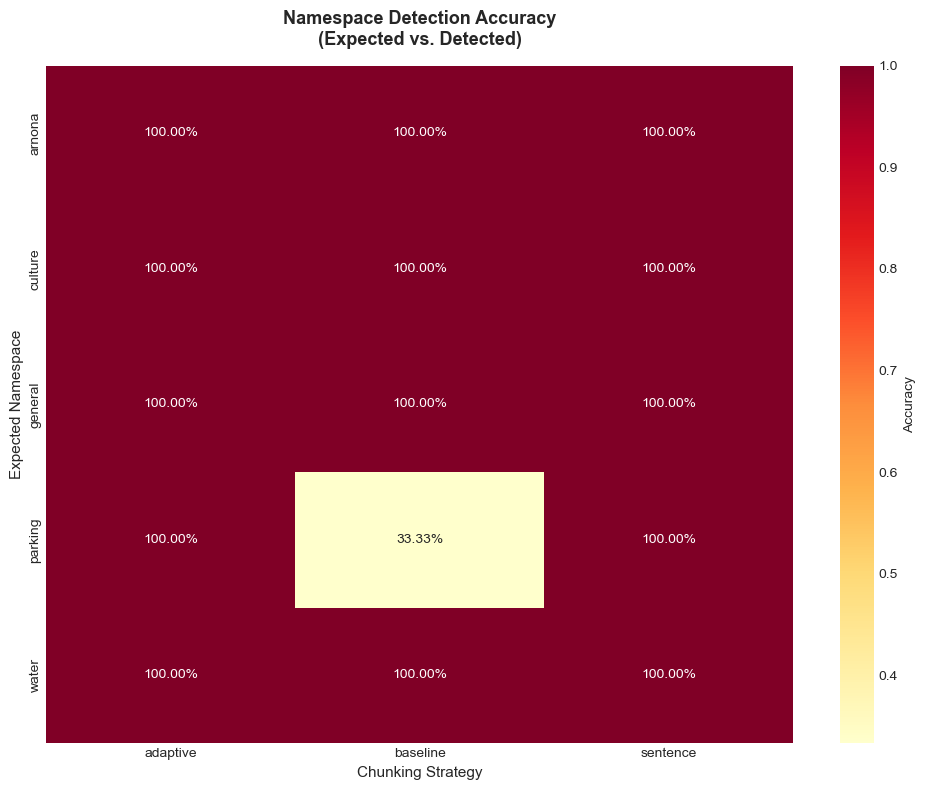

✅ Saved plot to results\namespace_accuracy_heatmap.png


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Namespace accuracy heatmap
if namespace_stats is not None and len(namespace_stats) > 0:
    # Filter to only show baseline, sentence, and adaptive strategies
    strategies_to_show = ['baseline', 'sentence', 'adaptive']
    namespace_filtered = namespace_stats[namespace_stats['strategy'].isin(strategies_to_show)].copy()
    
    # Aggregate duplicates by taking mean accuracy
    namespace_agg = namespace_filtered.groupby(
        ["expected_namespace", "strategy"], as_index=False
    )["accuracy"].mean()
    
    # Get all unique namespaces to ensure they all appear
    all_namespaces = sorted(namespace_stats['expected_namespace'].unique())
    
    pivot = namespace_agg.pivot(index="expected_namespace", columns="strategy", values="accuracy")
    
    # Reorder columns to: baseline, sentence, adaptive (in that exact order)
    final_columns = []
    for strat in strategies_to_show:
        if strat in pivot.columns:
            final_columns.append(strat)
    if final_columns:
        pivot = pivot[final_columns]
    
    # Ensure all namespaces are represented (add missing ones with NaN)
    missing_namespaces = set(all_namespaces) - set(pivot.index)
    if missing_namespaces:
        for ns in missing_namespaces:
            pivot.loc[ns] = [None] * len(pivot.columns)
    
    # Reindex to show all namespaces in sorted order
    pivot = pivot.reindex(all_namespaces)
    
    if len(pivot) > 0 and len(pivot.columns) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(pivot, annot=True, fmt=".2%", cmap="YlOrRd",
                    cbar_kws={"label": "Accuracy"}, ax=ax)
        ax.set_title("Namespace Detection Accuracy\n(Expected vs. Detected)", 
                     fontsize=13, fontweight="bold", pad=15)
        ax.set_xlabel("Chunking Strategy", fontsize=11)
        ax.set_ylabel("Expected Namespace", fontsize=11)
        
        # Set x-axis labels: Baseline, Sentence, Adaptive (capitalized, in that order)
        ax.set_xticklabels([s.capitalize() for s in pivot.columns], rotation=0)
        
        plt.tight_layout()

    else:
        print("⚠️ Cannot create heatmap: No namespace data available")
else:
    print("⚠️ Cannot create heatmap: No namespace statistics available")


## 6. Visualization - Category Analysis

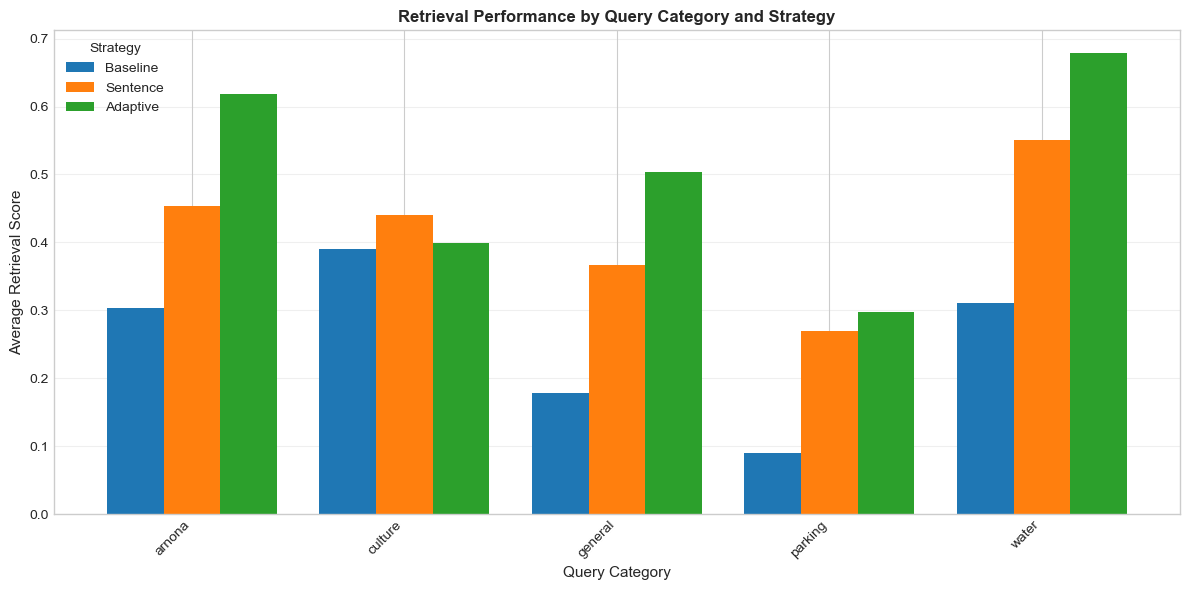

In [88]:
# Category analysis
strategy_order = ["baseline", "sentence", "adaptive"]
strategy_colors = {"baseline": "#1f77b4", "sentence": "#ff7f0e", "adaptive": "#2ca02c"}

category_strategy = df.groupby(["expected_namespace", "strategy"])["avg_score"].mean().reset_index()
pivot = category_strategy.pivot(index="expected_namespace", columns="strategy", values="avg_score")

# Reorder columns to ensure Baseline, Sentence, Adaptive order
columns_to_show = [s for s in strategy_order if s in pivot.columns]
pivot = pivot[columns_to_show]

# Get all categories (ensure all are shown)
all_categories = sorted(df["expected_namespace"].unique())
pivot = pivot.reindex(all_categories)

fig, ax = plt.subplots(figsize=(12, 6))
# Use colors in the same order as columns
colors = [strategy_colors[s] for s in columns_to_show]
pivot.plot(kind="bar", ax=ax, color=colors, width=0.8)
ax.set_ylabel("Average Retrieval Score", fontsize=11)
ax.set_xlabel("Query Category", fontsize=11)
ax.set_title("Retrieval Performance by Query Category and Strategy", 
             fontsize=12, fontweight="bold")
# Capitalize strategy names in legend
ax.legend(title="Strategy", title_fontsize=10, labels=[s.capitalize() for s in columns_to_show])
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

## 7. Summary and Conclusions

In [89]:
# Find best strategy
best_strategy = strategy_stats.loc[strategy_stats["avg_score_mean"].idxmax(), "strategy"]
best_avg_score = strategy_stats["avg_score_mean"].max()
overall_namespace_acc = df["namespace_correct"].mean()

print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"\n✅ Best Performing Strategy (by retrieval score): {best_strategy}")
print(f"   Average Retrieval Score: {best_avg_score:.4f}")
print(f"\n✅ Overall Namespace Detection Accuracy: {overall_namespace_acc:.2%}")

# Category-specific recommendations
print(f"\n📊 Performance by Category:")
category_best = df.groupby(["expected_namespace", "strategy"])["avg_score"].mean().reset_index()
category_best = category_best.loc[category_best.groupby("expected_namespace")["avg_score"].idxmax()]
for _, row in category_best.iterrows():
    print(f"  {row['expected_namespace']}: {row['strategy']} (score: {row['avg_score']:.4f})")

print(f"\n✅ All visualizations saved to: {RESULTS_DIR}")
print("=" * 70)

EVALUATION SUMMARY

✅ Best Performing Strategy (by retrieval score): adaptive
   Average Retrieval Score: 0.5259

✅ Overall Namespace Detection Accuracy: 98.33%

📊 Performance by Category:
  arnona: adaptive (score: 0.6191)
  culture: sentence (score: 0.4397)
  general: adaptive (score: 0.5040)
  parking: adaptive (score: 0.2971)
  water: adaptive (score: 0.6780)

✅ All visualizations saved to: results


## 8. Additional Analysis (Optional)

In [93]:
# Additional analysis: Query-level performance
from IPython.display import display

# Configure pandas display options for better readability
pd.set_option('display.max_colwidth', None)  # Show full text in columns
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

print("📊 Top performing queries by strategy:")
for strategy in df["strategy"].unique():
    strategy_df = df[df["strategy"] == strategy]
    # Group by query and namespace, taking average score to handle duplicates
    strategy_agg = strategy_df.groupby(["query", "expected_namespace"], as_index=False).agg({
        "avg_score": "mean"
    })
    top_queries = strategy_agg.nlargest(3, "avg_score")[["query", "expected_namespace", "avg_score"]].copy()
    top_queries.columns = ["Query", "Namespace", "Avg Score"]
    print(f"\n{strategy.upper()}:")
    display(top_queries)

# Additional analysis: Worst performing queries
# Group by query, strategy, and namespace, taking average score to handle duplicates
df_agg = df.groupby(["query", "strategy", "expected_namespace"], as_index=False).agg({
    "avg_score": "mean"
})
worst_queries = df_agg.nsmallest(5, "avg_score")[["query", "strategy", "expected_namespace", "avg_score"]].copy()
worst_queries.columns = ["Query", "Strategy", "Namespace", "Avg Score"]
print("\n\n📊 Queries with lowest scores:")
display(worst_queries)

📊 Top performing queries by strategy:

ADAPTIVE:


,Query,Namespace,Avg Score
19,מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?,arnona,0.691100
10,"איך פונים לשירותים כלליים שאינם תשלומים — למשל תלונות, פניות, שירותים חברתיים?",water,0.678045
8,איך משלמים ארנונה?,arnona,0.665450



BASELINE:


,Query,Namespace,Avg Score
19,מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?,arnona,0.470951
7,"איך מקבלים מידע על תרבות, מופעים, וסדנאות בעיר?",culture,0.390595
0,איך מגישים בקשה להנחות או פטור בארנונה?,arnona,0.341179



SENTENCE:


,Query,Namespace,Avg Score
19,מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?,arnona,0.611292
10,"איך פונים לשירותים כלליים שאינם תשלומים — למשל תלונות, פניות, שירותים חברתיים?",water,0.550890
14,האם ניתן ליצור קשר עם המוקד העירוני בנושאים שונים?,general,0.525510




📊 Queries with lowest scores:


,Query,Strategy,Namespace,Avg Score
34,אם אני רוצה להחליף מחזיק בנכס (למשל דירה שכורה) — איך מעדכנים את זה?,baseline,general,0.040784
13,איך מזמינים שירותי חינוך בלתי פורמלי כמו חוגים או סדנאות?,baseline,general,0.071984
40,"אם קיבלתי דוח פיקוח (חניה, פסולת, קנס וכו׳) — איך משלמים או מערערים?",baseline,parking,0.087105
7,איך מדווחים על חזירי בר או בעיות בטיחות בתושבים?,baseline,parking,0.092603
4,"איך מגישים בקשה לקבלת תעודת לידה, נישואין או תעודה אחרת?",baseline,general,0.102155


## 10. Comparison Across K Values

Compare performance for each strategy across different k values (k3, k5, k10).


📊 Performance by Strategy and K Value:
   strategy config  avg_score_mean  avg_score_std  namespace_correct_mean  \
0  adaptive    k10          0.5030         0.1347                     1.0   
1  adaptive     k3          0.5259         0.1247                     1.0   
2  adaptive     k5          0.5166         0.1284                     1.0   

   num_results_mean  
0              10.0  
1               3.0  
2               5.0  


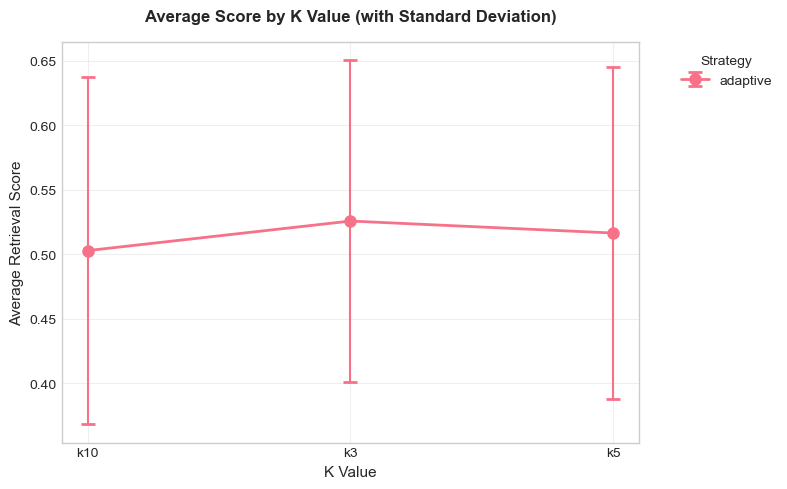


📈 Key Findings:
  adaptive: Best K = k3 (score: 0.5259)


In [ ]:
# Filter to k value configurations
k_configs = ['k3', 'k5', 'k10']
k_df = df[df['config'].isin(k_configs)].copy()

if len(k_df) > 0:
    # Use namespace accuracy as evaluation metric (better than avg_score for K comparison)
    # avg_score (retrieval similarity) is misleading for K comparison:
    # smaller K naturally yields higher avg similarity (top-K effect)
    # namespace_correct evaluates whether the right content namespace was retrieved
    eval_metric = 'namespace_correct'
    eval_label = 'Namespace Detection Accuracy'
    
    # Group by strategy and k value
    k_comparison = k_df.groupby(['strategy', 'config']).agg({
        eval_metric: ['mean', 'std'],
        'num_results': 'mean',
        'avg_score': 'mean'  # Keep for reference but don't use as primary metric
    }).round(4)
    k_comparison.columns = ['_'.join(col).strip() if col[1] else col[0] for col in k_comparison.columns]
    k_comparison = k_comparison.reset_index()
    
    # Sort by k value order (k3, k5, k10)
    k_order = ['k3', 'k5', 'k10']
    k_comparison['k_sort'] = k_comparison['config'].apply(lambda x: k_order.index(x) if x in k_order else 999)
    k_comparison = k_comparison.sort_values(['strategy', 'k_sort']).drop('k_sort', axis=1).reset_index(drop=True)
    
    print("📊 Performance by Strategy and K Value:")
    print(k_comparison)
    
    # Visualization: Evaluation metric by K value
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create mapping for proper ordering and labeling
    k_order = ['k3', 'k5', 'k10']
    k_labels = {'k3': '3', 'k5': '5', 'k10': '10'}
    k_numeric = {'k3': 3, 'k5': 5, 'k10': 10}
    
    # Evaluation metric by k value with error bars
    metric_col = f"{eval_metric}_mean"
    std_col = f"{eval_metric}_std"
    
    for strategy in k_df['strategy'].unique():
        strategy_data = k_comparison[k_comparison['strategy'] == strategy].copy()
        # Sort by k value order
        strategy_data['k_numeric'] = strategy_data['config'].map(k_numeric)
        strategy_data = strategy_data.sort_values('k_numeric')
        
        # Convert config to numeric for plotting
        x_values = strategy_data['config'].map(k_numeric).values
        y_values = strategy_data[metric_col].values
        yerr = strategy_data[std_col].values
        
        # Plot with error bars (gray, less emphasized)
        ax.errorbar(x_values, y_values, yerr=yerr, 
                   marker='o', label=strategy, linewidth=2, markersize=8,
                   capsize=4, capthick=1.5, elinewidth=1.5,
                   ecolor='lightgray')
    
    # Set x-axis ticks and labels
    ax.set_xticks([3, 5, 10])
    ax.set_xticklabels(['3', '5', '10'])
    ax.set_xlabel('K Value', fontsize=11)
    ax.set_ylabel(eval_label, fontsize=11)
    ax.set_title(f'{eval_label} by K Value', fontsize=12, fontweight='bold', pad=15)
    ax.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')  # optional: move legend outside
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Key Findings:")
    for strategy in k_df['strategy'].unique():
        strategy_data = k_comparison[k_comparison['strategy'] == strategy]
        if len(strategy_data) > 0:
            best_k = strategy_data.loc[strategy_data[metric_col].idxmax(), 'config']
            best_score = strategy_data[metric_col].max()
            print(f"  {strategy}: Best K = {best_k} ({eval_label}: {best_score:.4f})")
else:
    print("⚠️  No k value configurations found. Ensure results_k3, results_k5, results_k10 exist.")

## 11. Comparison Across Chunk Sizes

Compare performance for each strategy across different chunk sizes (small, medium).


📊 Performance by Strategy and Chunk Size:
   strategy         config  avg_score_mean  avg_score_std  \
0  adaptive  medium_chunks          0.5156         0.1307   
1  adaptive   small_chunks          0.5166         0.1284   
2  baseline  medium_chunks          0.1865         0.1131   
3  baseline   small_chunks          0.2796         0.1324   
4  sentence  medium_chunks          0.3792         0.1155   
5  sentence   small_chunks          0.4177         0.1207   

   namespace_correct_mean  num_results_mean  unique_docs_mean  
0                     1.0               5.0              3.65  
1                     1.0               5.0              3.50  
2                     0.9               3.7              3.60  
3                     1.0               4.9              4.25  
4                     1.0               5.0              4.40  
5                     1.0               5.0              3.90  


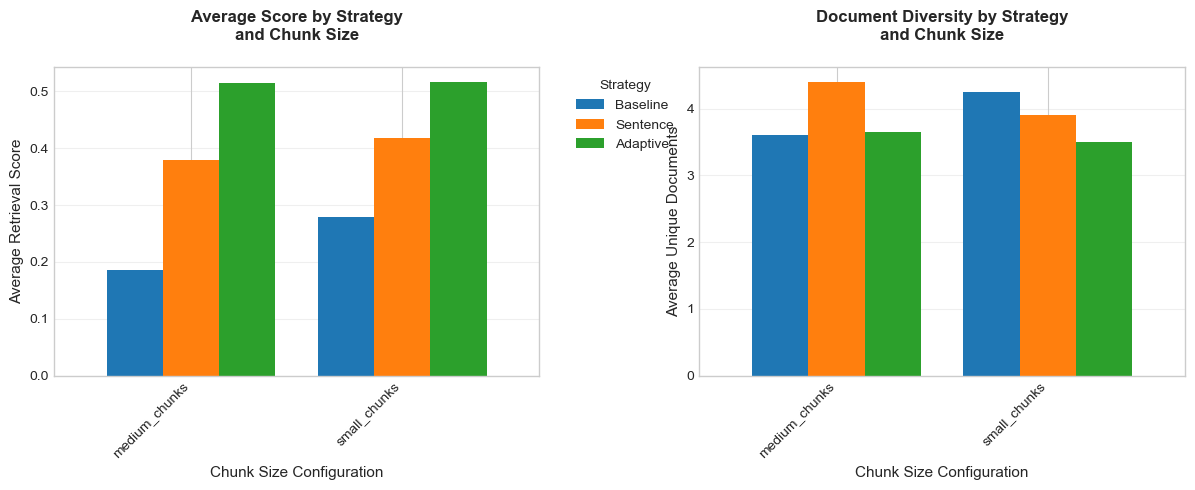


📈 Key Findings:
  baseline: Best chunk size = small_chunks (score: 0.2796)
  sentence: Best chunk size = small_chunks (score: 0.4177)
  adaptive: Best chunk size = small_chunks (score: 0.5166)


In [ ]:
# Filter to chunk size configurations
chunk_configs = ['small_chunks', 'medium_chunks']
chunk_df = df[df['config'].isin(chunk_configs)].copy()

if len(chunk_df) > 0:
    # Group by strategy and chunk size
    chunk_comparison = chunk_df.groupby(['strategy', 'config']).agg({
        'avg_score': ['mean', 'std'],
        'namespace_correct': 'mean',
        'num_results': 'mean',
        'unique_docs': 'mean'
    }).round(4)
    chunk_comparison.columns = ['_'.join(col).strip() if col[1] else col[0] for col in chunk_comparison.columns]
    chunk_comparison = chunk_comparison.reset_index()
    
    print("📊 Performance by Strategy and Chunk Size:")
    print(chunk_comparison)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Define strategy order: Baseline, Sentence, Adaptive
    strategy_order = ['baseline', 'sentence', 'adaptive']
    strategy_colors = {'baseline': '#1f77b4', 'sentence': '#ff7f0e', 'adaptive': '#2ca02c'}
    
    # Average score by chunk size
    ax = axes[0]
    chunk_means = chunk_df.groupby(['strategy', 'config'])['avg_score'].mean().reset_index()
    pivot_score = chunk_means.pivot(index='config', columns='strategy', values='avg_score')
    # Reorder columns to match strategy_order
    columns_to_show = [s for s in strategy_order if s in pivot_score.columns]
    pivot_score = pivot_score[columns_to_show]
    colors = [strategy_colors[s] for s in columns_to_show]
    pivot_score.plot(kind='bar', ax=ax, width=0.8, color=colors)
    ax.set_xlabel('Chunk Size Configuration', fontsize=11)
    ax.set_ylabel('Average Retrieval Score', fontsize=11)
    ax.set_title('Average Score by Strategy\nand Chunk Size', fontsize=12, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.get_legend().remove()  # Remove second legend

    # Unique docs by chunk size
    ax = axes[1]
    unique_docs_means = chunk_df.groupby(['strategy', 'config'])['unique_docs'].mean().reset_index()
    pivot_docs = unique_docs_means.pivot(index='config', columns='strategy', values='unique_docs')
    # Reorder columns to match strategy_order
    columns_to_show = [s for s in strategy_order if s in pivot_docs.columns]
    pivot_docs = pivot_docs[columns_to_show]
    colors = [strategy_colors[s] for s in columns_to_show]
    pivot_docs.plot(kind='bar', ax=ax, width=0.8, color=colors)
    ax.set_xlabel('Chunk Size Configuration', fontsize=11)
    ax.set_ylabel('Average Unique Documents', fontsize=11)
    ax.set_title('Document Diversity by Strategy\nand Chunk Size', fontsize=12, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(title='Strategy', labels=[s.capitalize() for s in columns_to_show], 
              bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    fig.subplots_adjust(right=0.85)  # make room for legend outside
    plt.show()
    
    print("\n📈 Key Findings:")
    for strategy in chunk_df['strategy'].unique():
        strategy_data = chunk_comparison[chunk_comparison['strategy'] == strategy]
        if len(strategy_data) > 0:
            best_chunk = strategy_data.loc[strategy_data['avg_score_mean'].idxmax(), 'config']
            best_score = strategy_data['avg_score_mean'].max()
            print(f"  {strategy}: Best chunk size = {best_chunk} (score: {best_score:.4f})")
else:
    print("⚠️  No chunk size configurations found. Ensure small_chunks and medium_chunks exist.")

## 12. Comparison Across Overlap Sizes

Compare performance for each strategy across different overlap sizes (small_overlap, medium_chunks).



🔍 Data verification:
  small_overlap: 60 rows, unique avg_scores: 60
    Sample avg_score range: [0.0232, 0.7107]
  medium_chunks: 60 rows, unique avg_scores: 60
    Sample avg_score range: [0.0232, 0.7107]
📊 Performance by Strategy and Overlap Size:
   strategy         config  avg_score_mean  avg_score_std  \
0  adaptive  medium_chunks          0.5156         0.1307   
1  adaptive  small_overlap          0.5156         0.1307   
2  baseline  medium_chunks          0.1865         0.1131   
3  baseline  small_overlap          0.1865         0.1131   
4  sentence  medium_chunks          0.3792         0.1155   
5  sentence  small_overlap          0.3792         0.1155   

   namespace_correct_mean  num_results_mean  
0                     1.0               5.0  
1                     1.0               5.0  
2                     0.9               3.7  
3                     0.9               3.7  
4                     1.0               5.0  
5                     1.0               5.0 

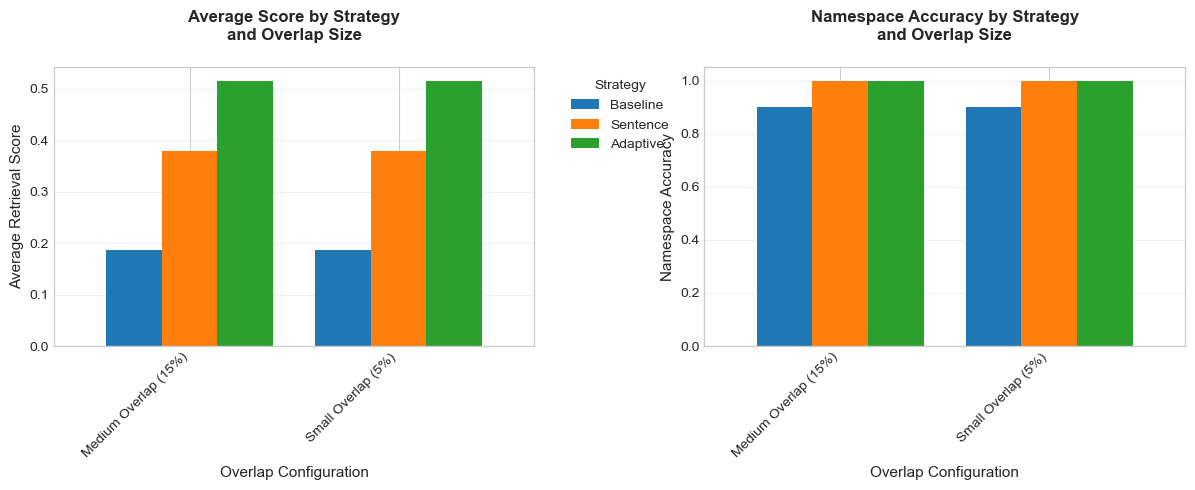


📈 Key Findings:
  baseline: Best overlap = medium_chunks (score: 0.1865)
  sentence: Best overlap = medium_chunks (score: 0.3792)
  adaptive: Best overlap = medium_chunks (score: 0.5156)


In [108]:
# Filter to overlap configurations (medium_chunks has overlap 150, small_overlap has overlap 50)
overlap_configs = ['small_overlap', 'medium_chunks']
overlap_df = df[df['config'].isin(overlap_configs)].copy()

if len(overlap_df) > 0:
    # Debug: Check if data is different between configs
    print(f"\n🔍 Data verification:")
    for config in overlap_configs:
        config_data = overlap_df[overlap_df['config'] == config]
        print(f"  {config}: {len(config_data)} rows, unique avg_scores: {config_data['avg_score'].nunique()}")
        if len(config_data) > 0:
            print(f"    Sample avg_score range: [{config_data['avg_score'].min():.4f}, {config_data['avg_score'].max():.4f}]")
    
    # Map config names to overlap sizes for clarity
    overlap_df['overlap_label'] = overlap_df['config'].map({
        'small_overlap': 'Small Overlap (5%)',
        'medium_chunks': 'Medium Overlap (15%)'
    })
    
    # Group by strategy and config
    overlap_comparison = overlap_df.groupby(['strategy', 'config']).agg({
        'avg_score': ['mean', 'std'],
        'namespace_correct': 'mean',
        'num_results': 'mean'
    }).round(4)
    overlap_comparison.columns = ['_'.join(col).strip() if col[1] else col[0] for col in overlap_comparison.columns]
    overlap_comparison = overlap_comparison.reset_index()
    
    print("📊 Performance by Strategy and Overlap Size:")
    print(overlap_comparison)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Define strategy order: Baseline, Sentence, Adaptive
    strategy_order = ['baseline', 'sentence', 'adaptive']
    strategy_colors = {'baseline': '#1f77b4', 'sentence': '#ff7f0e', 'adaptive': '#2ca02c'}
    
    # Average score by overlap
    ax = axes[0]
    overlap_means = overlap_df.groupby(['strategy', 'overlap_label'])['avg_score'].mean().reset_index()
    pivot_score = overlap_means.pivot(index='overlap_label', columns='strategy', values='avg_score')
    # Reorder columns to match strategy_order
    columns_to_show = [s for s in strategy_order if s in pivot_score.columns]
    pivot_score = pivot_score[columns_to_show]
    colors = [strategy_colors[s] for s in columns_to_show]
    pivot_score.plot(kind='bar', ax=ax, width=0.8, color=colors)
    ax.set_xlabel('Overlap Configuration', fontsize=11)
    ax.set_ylabel('Average Retrieval Score', fontsize=11)
    ax.set_title('Average Score by Strategy\nand Overlap Size', fontsize=12, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(title='Strategy', labels=[s.capitalize() for s in columns_to_show], 
              bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Namespace accuracy by overlap
    ax = axes[1]
    namespace_acc_overlap = overlap_df.groupby(['strategy', 'overlap_label'])['namespace_correct'].mean().reset_index()
    pivot_acc = namespace_acc_overlap.pivot(index='overlap_label', columns='strategy', values='namespace_correct')
    # Reorder columns to match strategy_order
    columns_to_show = [s for s in strategy_order if s in pivot_acc.columns]
    pivot_acc = pivot_acc[columns_to_show]
    colors = [strategy_colors[s] for s in columns_to_show]
    pivot_acc.plot(kind='bar', ax=ax, width=0.8, color=colors)
    ax.set_xlabel('Overlap Configuration', fontsize=11)
    ax.set_ylabel('Namespace Accuracy', fontsize=11)
    ax.set_title('Namespace Accuracy by Strategy\nand Overlap Size', fontsize=12, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.get_legend().remove()  # Remove second legend
    
    plt.tight_layout()
    fig.subplots_adjust(right=0.85)  # make room for legend
    plt.show()
    
    print("\n📈 Key Findings:")
    for strategy in overlap_df['strategy'].unique():
        strategy_data = overlap_comparison[overlap_comparison['strategy'] == strategy]
        if len(strategy_data) > 0:
            best_overlap = strategy_data.loc[strategy_data['avg_score_mean'].idxmax(), 'config']
            best_score = strategy_data['avg_score_mean'].max()
            print(f"  {strategy}: Best overlap = {best_overlap} (score: {best_score:.4f})")
else:
    print("⚠️  No overlap configurations found. Ensure small_overlap and medium_chunks exist.")

In [103]:
# Analyze answer quality if answers were generated
if ENABLE_ANSWER_ANALYSIS and "llm_score" in df.columns and "answer" in df.columns:
    print("📊 Answer Quality Analysis:")
    print("=" * 70)
    
    # LLM score by strategy
    llm_by_strategy = df.groupby("strategy")["llm_score"].agg(["mean", "std", "count"]).round(4)
    print("\nLLM Answer Quality Score by Strategy:")
    print(llm_by_strategy)
    
    # Precision/Recall if available
    if "precision_at_k" in df.columns and "recall_at_k" in df.columns:
        pr_by_strategy = df.groupby("strategy")[["precision_at_k", "recall_at_k"]].mean().round(4)
        print("\nPrecision and Recall by Strategy:")
        print(pr_by_strategy)
        
        # Plot precision/recall
        fig, ax = plt.subplots(figsize=(10, 6))
        pr_by_strategy.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
        ax.set_ylabel("Score", fontsize=11)
        ax.set_xlabel("Chunking Strategy", fontsize=11)
        ax.set_title("Precision and Recall by Strategy", fontsize=12, fontweight="bold")
        ax.legend(title="Metric")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "precision_recall_by_strategy.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✅ Saved plot to {RESULTS_DIR / 'precision_recall_by_strategy.png'}")
    
    # Plot LLM scores
    fig, ax = plt.subplots(figsize=(10, 6))
    llm_means = df.groupby("strategy")["llm_score"].mean().sort_values(ascending=False)
    bars = ax.bar(llm_means.index, llm_means.values, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    ax.set_ylabel("Average LLM Quality Score", fontsize=11)
    ax.set_xlabel("Chunking Strategy", fontsize=11)
    ax.set_title("Answer Quality by Strategy (LLM Grading)", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    for i, (strategy, val) in enumerate(llm_means.items()):
        ax.text(i, val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "llm_score_by_strategy.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved plot to {RESULTS_DIR / 'llm_score_by_strategy.png'}")
    
else:
    print("ℹ️ Answer evaluation data not available in results.")
    print("   To enable answer evaluation, modify the evaluation script to generate answers.")

ℹ️ Answer evaluation data not available in results.
   To enable answer evaluation, modify the evaluation script to generate answers.
